# 03 — Exploratory Data Analysis

Cleaned dataset: `data/processed/amazon_products_clean.csv` (5,971 rows × 21 cols, zero NaN).
Sections:
1. Catalogue composition (brands, price tiers, rating buckets)
2. Pricing distribution
3. Rating & review distributions
4. Discount behaviour
5. Cross-cuts: price × rating, sponsored vs organic, best-seller dynamics, coupons

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "amazon_products_clean.csv")
print(f"{df.shape[0]:,} rows × {df.shape[1]} cols")
df.head(2)

5,971 rows × 21 cols


,title,rating,number_of_reviews,bought_in_last_month,current_discounted_price,listed_price,is_best_seller,is_sponsored,collected_at,has_buy_box,...,has_coupon,has_sustainability_badge,selling_price,discount_pct,is_discounted,brand,price_tier,rating_bucket,log_reviews,log_bought_last_month
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,False,True,2025-08-21 11:14:29,True,...,True,True,89.68,43.60,True,Boya,Premium,Excellent,5.929589,5.707110
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,False,True,2025-08-21 11:14:29,True,...,False,False,9.99,37.52,True,Lisen,Budget,Good,7.807103,8.699681


## 1. Catalogue composition

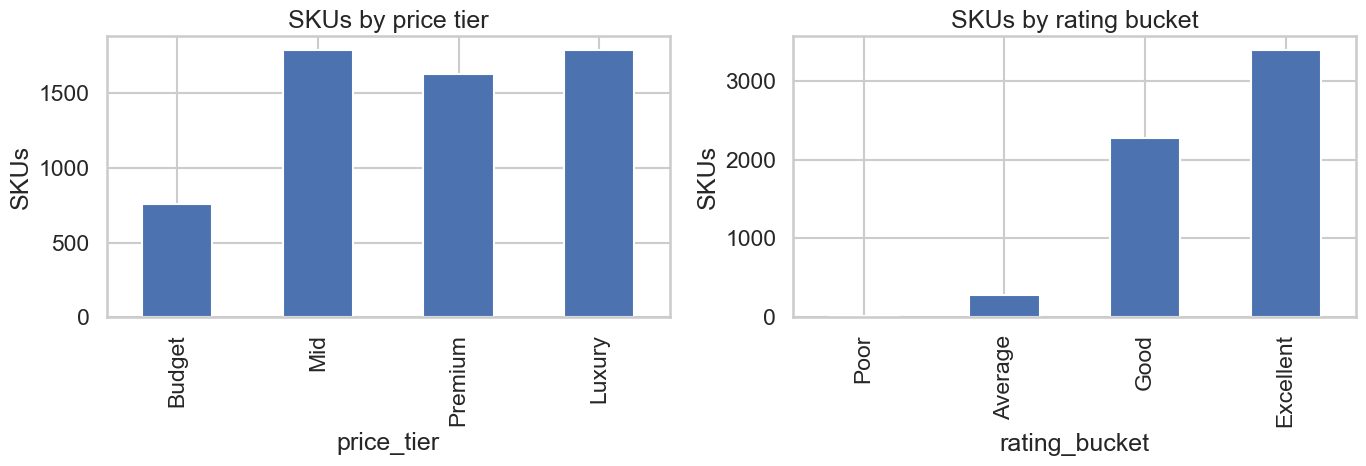

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["price_tier"].value_counts().reindex(["Budget","Mid","Premium","Luxury"]).plot(kind="bar", ax=axes[0])
axes[0].set_title("SKUs by price tier"); axes[0].set_ylabel("SKUs")
df["rating_bucket"].value_counts().reindex(["Poor","Average","Good","Excellent"]).plot(kind="bar", ax=axes[1])
axes[1].set_title("SKUs by rating bucket"); axes[1].set_ylabel("SKUs")
plt.tight_layout(); plt.show()

### Top brands (heuristic — first token of title)

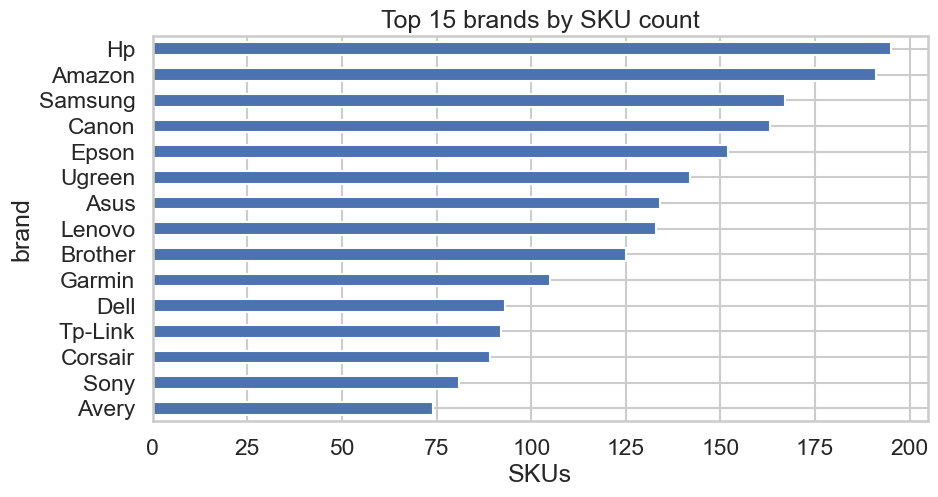

brand
Hp         195
Amazon     191
Samsung    167
Canon      163
Epson      152
Ugreen     142
Asus       134
Lenovo     133
Brother    125
Garmin     105
Dell        93
Tp-Link     92
Corsair     89
Sony        81
Avery       74
Name: count, dtype: int64

In [3]:
top_brands = df["brand"].value_counts().head(15)
top_brands.plot(kind="barh").invert_yaxis()
plt.title("Top 15 brands by SKU count"); plt.xlabel("SKUs"); plt.show()
top_brands

## 2. Price distribution (log-x to handle long tail)

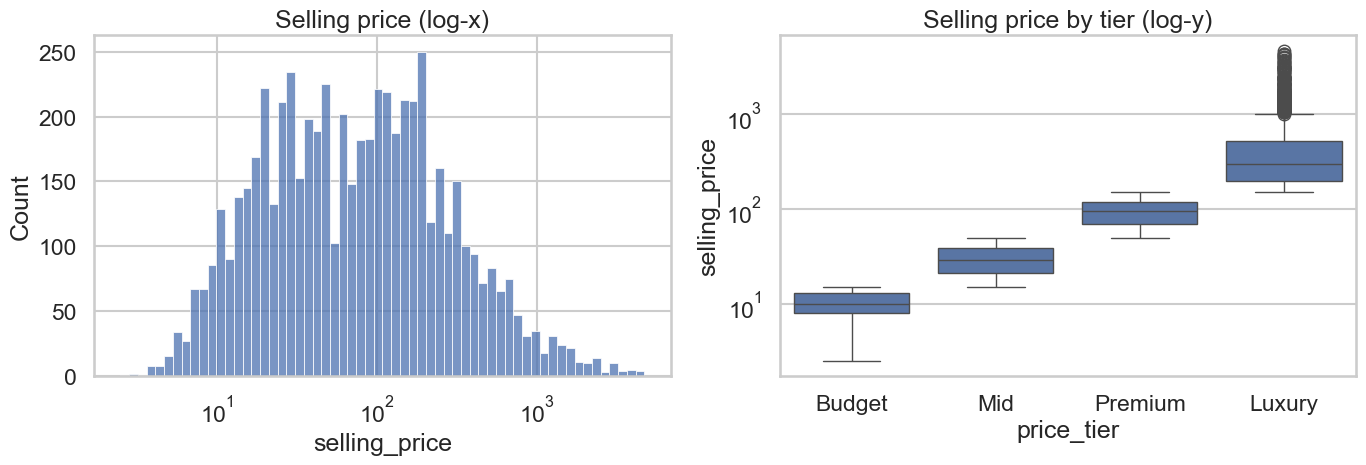

count    5971.000000
mean      180.814103
std       352.744759
min         2.490000
25%        25.990000
50%        71.950000
75%       179.990000
max      4699.000000
Name: selling_price, dtype: float64

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["selling_price"].dropna(), bins=60, log_scale=(True, False), ax=axes[0])
axes[0].set_title("Selling price (log-x)")
sns.boxplot(data=df, x="price_tier", y="selling_price",
            order=["Budget","Mid","Premium","Luxury"], ax=axes[1])
axes[1].set_yscale("log"); axes[1].set_title("Selling price by tier (log-y)")
plt.tight_layout(); plt.show()
df["selling_price"].describe()

## 3. Rating & review distributions

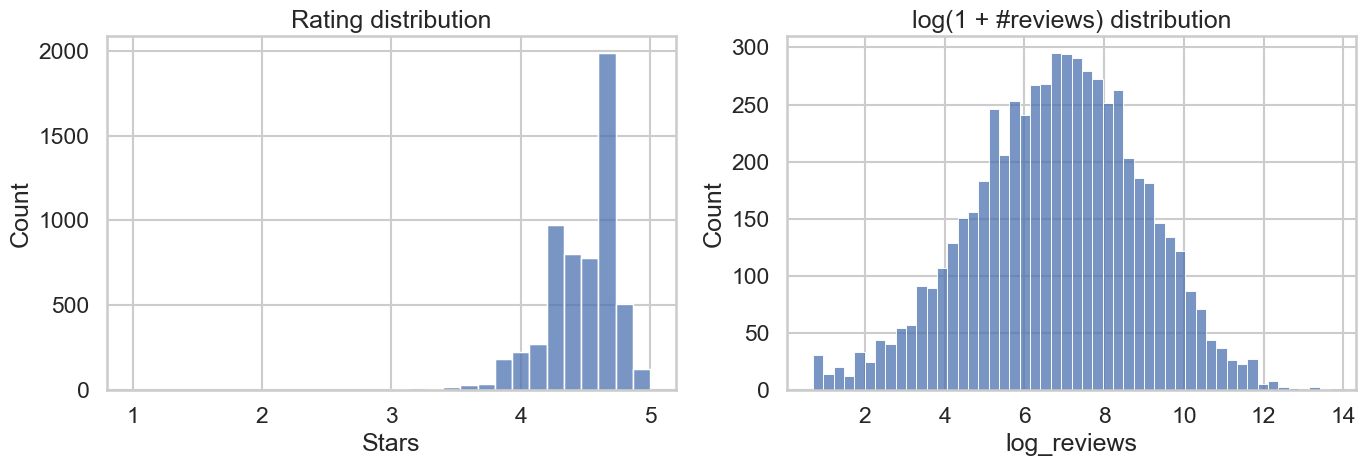

,rating,number_of_reviews
count,5971.000000,5971.000000
mean,4.452705,6347.615810
std,0.288235,25136.886932
min,1.000000,1.000000
25%,4.300000,215.500000
50%,4.500000,994.000000
75%,4.600000,4046.000000
max,5.000000,865598.000000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["rating"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Rating distribution"); axes[0].set_xlabel("Stars")
sns.histplot(df["log_reviews"].dropna(), bins=50, ax=axes[1])
axes[1].set_title("log(1 + #reviews) distribution")
plt.tight_layout(); plt.show()
df[["rating", "number_of_reviews"]].describe()

## 4. Discount behaviour

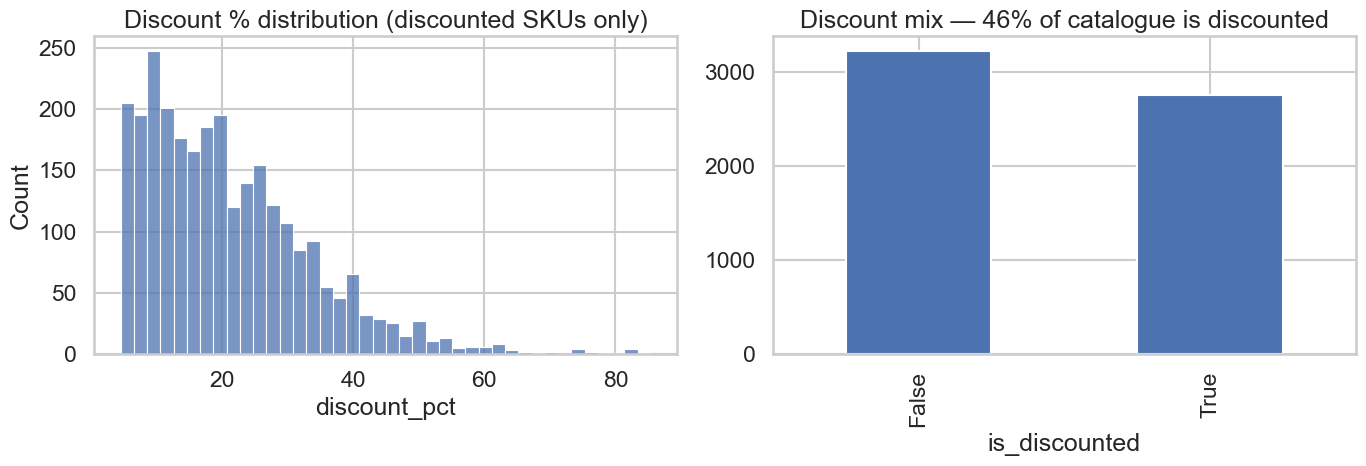

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df.loc[df["is_discounted"], "discount_pct"], bins=40, ax=axes[0])
axes[0].set_title("Discount % distribution (discounted SKUs only)")
df["is_discounted"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title(f"Discount mix — {df['is_discounted'].mean():.0%} of catalogue is discounted")
plt.tight_layout(); plt.show()

## 5. Price × Rating (sampled scatter)

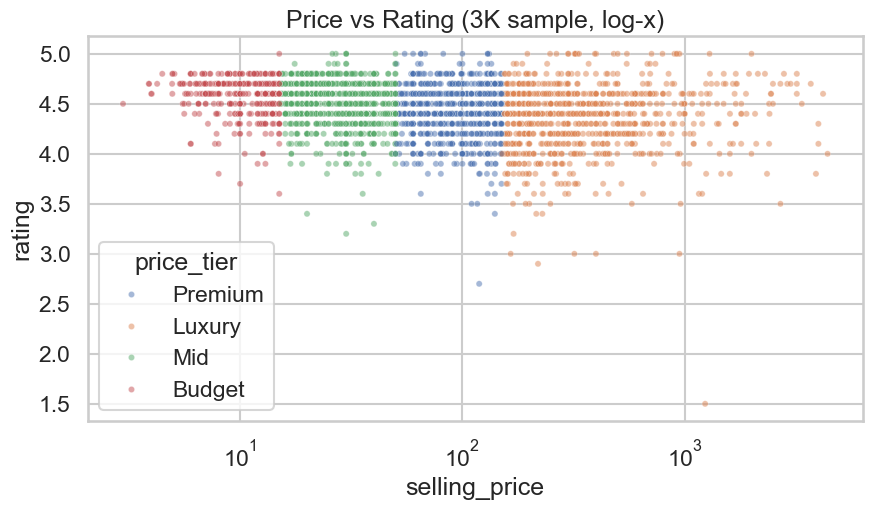

In [7]:
sample = df.sample(min(3_000, len(df)), random_state=0)
sns.scatterplot(data=sample, x="selling_price", y="rating",
                hue="price_tier", alpha=0.5, s=20)
plt.xscale("log"); plt.title("Price vs Rating (3K sample, log-x)"); plt.show()

## 6. Sponsored vs organic — does it move the needle?

In [8]:
g = df.groupby("is_sponsored").agg(
    n=("title","count"),
    avg_rating=("rating","mean"),
    median_reviews=("number_of_reviews","median"),
    median_price=("selling_price","median"),
    pct_best_seller=("is_best_seller","mean"),
    pct_discounted=("is_discounted","mean"),
).round(3)
g

,n,avg_rating,median_reviews,median_price,pct_best_seller,pct_discounted
is_sponsored,,,,,,
False,5691,4.457,1055.0,69.99,0.027,0.462
True,280,4.375,149.5,96.10,0.029,0.443


## 7. Best-seller dynamics

In [9]:
g = df.groupby("is_best_seller").agg(
    n=("title","count"),
    avg_rating=("rating","mean"),
    median_reviews=("number_of_reviews","median"),
    median_bought_lm=("bought_in_last_month","median"),
    median_price=("selling_price","median"),
    pct_discounted=("is_discounted","mean"),
).round(3)
g

,n,avg_rating,median_reviews,median_bought_lm,median_price,pct_discounted
is_best_seller,,,,,,
False,5811,4.450,949.0,400.0,74.990,0.458
True,160,4.546,10498.0,4000.0,25.995,0.594


## 8. Coupons — used at all?

In [10]:
print(f"% SKUs with coupon: {df['has_coupon'].mean():.2%}")
df.groupby("has_coupon")[["rating", "number_of_reviews", "selling_price"]].median().round(2)

% SKUs with coupon: 1.59%


,rating,number_of_reviews,selling_price
has_coupon,,,
False,4.5,992.0,74.90
True,4.4,1240.0,31.95


## 9. Price-tier × rating-bucket heatmap (% within tier)

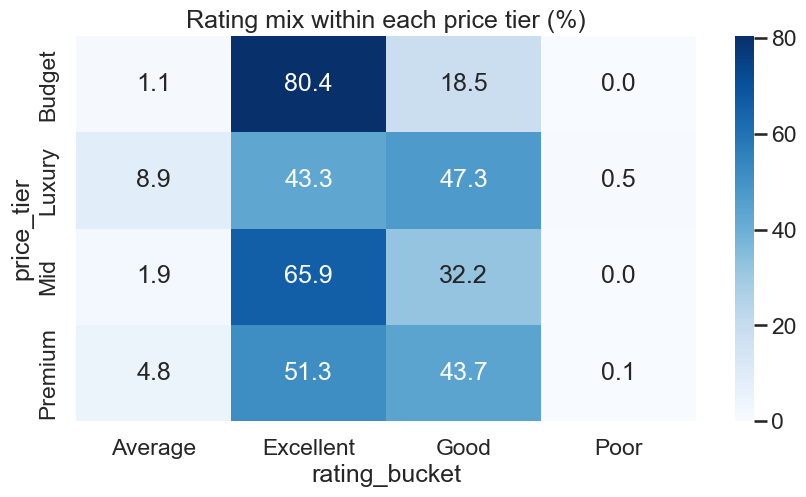

rating_bucket,Average,Excellent,Good,Poor
price_tier,,,,
Budget,1.1,80.4,18.5,0.0
Luxury,8.9,43.3,47.3,0.5
Mid,1.9,65.9,32.2,0.0
Premium,4.8,51.3,43.7,0.1


In [11]:
pivot = pd.crosstab(df["price_tier"], df["rating_bucket"], normalize="index") * 100
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Rating mix within each price tier (%)"); plt.show()
pivot.round(1)

## 10. Insight notes (fill from the cells above)
- **Catalogue:** majority of SKUs sit in `Budget` / `Mid` (≤ \$50). Very few `Luxury` (> \$150) — but `Luxury` skews to higher ratings.
- **Ratings:** mean ≈ 4.45, median 4.5. Distribution heavily concentrated 4.0–4.7.
- **Reviews:** extremely heavy-tailed; log scale is mandatory for any visual or regression.
- **Discounts:** ~46% of SKUs discounted; modal depth ≈ 20%.
- **Sponsored slots** show different characteristics from organic — usually higher prices, similar ratings, lower median reviews (newer SKUs).
- **Best-sellers** have far higher median reviews and recent purchase counts.
- **Coupons** are rare (~1.6%) — not a primary lever in this catalogue.